In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Indian_Startup_Funding_Dataset.csv")
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()
print("\nStatistical Summary:")
df.describe()
print(df.dtypes)


Shape of dataset: (300, 11)

First 5 rows:
   Startup_ID Startup_Name       Industry       City        State  \
0           1  Startup_001  Cybersecurity       Pune  Maharashtra   
1           2  Startup_002     E-commerce       Pune  Maharashtra   
2           3  Startup_003       AgriTech  Ahmedabad      Gujarat   
3           4  Startup_004         EdTech  Hyderabad    Telangana   
4           5  Startup_005         EdTech     Jaipur    Rajasthan   

   Funding_Year Funding_Stage   Lead_Investor  Funding_Amount_USD  Employees  \
0          2025      Series A  Blume Ventures            20300000        417   
1          2025  Pre-Series A           Accel            12200000        406   
2          2022          Seed           Accel             8300000        362   
3          2025      Series C         Peak XV            43800000        393   
4          2018  Pre-Series A  Blume Ventures            36800000        476   

   Status  
0  Active  
1  Active  
2  Active  
3  Active  
4

In [6]:
missing_values = df.isnull().sum()

print(missing_values)

Startup_ID            0
Startup_Name          0
Industry              0
City                  0
State                 0
Funding_Year          0
Funding_Stage         0
Lead_Investor         0
Funding_Amount_USD    0
Employees             0
Status                0
dtype: int64


In [39]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

print("Duplicate Startup IDs:",
      df['Startup_ID'].duplicated().sum())
print("Industries:")
print(df['Industry'].unique())

print("\nCities:")
print(df['City'].unique())

print("\nFunding Stages:")
print(df['Funding_Stage'].unique())

print("\nInvestors:")
print(df['Lead_Investor'].unique())

print("\nStatus:")
print(df['Status'].unique())

Number of duplicate rows: 0
Duplicate Startup IDs: 0
Industries:
<StringArray>
['Cybersecurity',    'E-commerce',      'AgriTech',        'EdTech',
          'SaaS',     'Logistics',       'FinTech',            'AI',
     'CleanTech',    'HealthTech']
Length: 10, dtype: str

Cities:
<StringArray>
[     'Pune', 'Ahmedabad', 'Hyderabad',    'Jaipur',     'Noida',     'Delhi',
   'Kolkata', 'Bengaluru',    'Mumbai',   'Chennai']
Length: 10, dtype: str

Funding Stages:
<StringArray>
['Series A', 'Pre-Series A', 'Seed', 'Series C', 'Series B']
Length: 5, dtype: str

Investors:
<StringArray>
[        'Blume Ventures',                  'Accel',                'Peak XV',
 'Nexus Venture Partners',           'Tiger Global',        'Matrix Partners',
        'Kalaari Capital',        'Sequoia Capital']
Length: 8, dtype: str

Status:
<StringArray>
['Active']
Length: 1, dtype: str


In [40]:
print(df['Industry'].value_counts())
print(df['City'].value_counts())
print(df['Funding_Stage'].value_counts())
print(df['Lead_Investor'].value_counts())
print(df['Status'].value_counts())

Industry
EdTech           40
CleanTech        39
FinTech          38
Cybersecurity    33
E-commerce       32
SaaS             26
Logistics        24
HealthTech       24
AgriTech         22
AI               22
Name: count, dtype: int64
City
Ahmedabad    40
Delhi        39
Bengaluru    33
Kolkata      29
Pune         28
Jaipur       28
Hyderabad    27
Noida        27
Chennai      26
Mumbai       23
Name: count, dtype: int64
Funding_Stage
Seed            66
Series A        65
Series C        58
Series B        58
Pre-Series A    53
Name: count, dtype: int64
Lead_Investor
Sequoia Capital           45
Blume Ventures            42
Nexus Venture Partners    42
Accel                     41
Tiger Global              37
Kalaari Capital           33
Peak XV                   32
Matrix Partners           28
Name: count, dtype: int64
Status
Active    300
Name: count, dtype: int64


In [41]:
df.columns

Index(['Startup_ID', 'Startup_Name', 'Industry', 'City', 'State',
       'Funding_Year', 'Funding_Stage', 'Lead_Investor', 'Funding_Amount_USD',
       'Employees', 'Status'],
      dtype='str')

In [42]:
numeric_columns = [
    'Funding_Amount_USD',
    'Employees'
]

print(df[numeric_columns].describe())
print("Negative funding values:",
      (df['Funding_Amount_USD'] < 0).sum())

print("Negative employee values:",
      (df['Employees'] < 0).sum())

       Funding_Amount_USD   Employees
count        3.000000e+02  300.000000
mean         2.474900e+07  250.030000
std          1.471352e+07  144.001588
min          1.000000e+05    6.000000
25%          1.190000e+07  129.000000
50%          2.470000e+07  240.000000
75%          3.800000e+07  375.750000
max          4.950000e+07  500.000000
Negative funding values: 0
Negative employee values: 0


In [43]:
Q1 = df['Funding_Amount_USD'].quantile(0.25)
Q3 = df['Funding_Amount_USD'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['Funding_Amount_USD'] < lower_limit) |
    (df['Funding_Amount_USD'] > upper_limit)
]

print("Number of funding outliers:", len(outliers))

Q1 = df['Employees'].quantile(0.25)
Q3 = df['Employees'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

employee_outliers = df[
    (df['Employees'] < lower_limit) |
    (df['Employees'] > upper_limit)
]

print("Number of employee outliers:",
      len(employee_outliers))

Number of funding outliers: 0
Number of employee outliers: 0


In [44]:
df['Funding_Million_USD'] = (
    df['Funding_Amount_USD'] / 1_000_000
)

print(df[['Funding_Amount_USD',
          'Funding_Million_USD']].head())
year_funding = (
    df.groupby('Funding_Year')['Funding_Amount_USD']
      .sum()
      .sort_index()
)

print(year_funding)
industry_funding = (
    df.groupby('Industry')['Funding_Amount_USD']
      .sum()
      .sort_values(ascending=False)
)

print(industry_funding)

city_funding = (
    df.groupby('City')['Funding_Amount_USD']
      .sum()
      .sort_values(ascending=False)
)

print(city_funding / 1_000_000)

investor_funding = (
    df.groupby('Lead_Investor')['Funding_Amount_USD']
      .sum()
      .sort_values(ascending=False)
)

print(investor_funding / 1_000_000)

stage_funding = (
    df.groupby('Funding_Stage')['Funding_Amount_USD']
      .sum()
      .sort_values(ascending=False)
)

print(stage_funding / 1_000_000)


top_10_startups = df.nlargest(
    10,
    'Funding_Amount_USD'
)

print(
    top_10_startups[
        [
            'Startup_Name',
            'Industry',
            'City',
            'Funding_Stage',
            'Funding_Amount_USD'
        ]
    ]
)
average_funding = df['Funding_Amount_USD'].mean()

print(
    "Average funding: $",
    round(average_funding / 1_000_000, 2),
    "Million"
)
total_funding = df['Funding_Amount_USD'].sum()

print(
    "Total funding: $",
    round(total_funding / 1_000_000, 2),
    "Million"
)
total_startups = df['Startup_ID'].nunique()

print("Total startups:", total_startups)

total_investors = df['Lead_Investor'].nunique()

print("Total investors:", total_investors)

total_employees = df['Employees'].sum()

print("Total employees:", total_employees)


   Funding_Amount_USD  Funding_Million_USD
0            20300000                 20.3
1            12200000                 12.2
2             8300000                  8.3
3            43800000                 43.8
4            36800000                 36.8
Funding_Year
2018     949000000
2019     905600000
2020     645900000
2021     699000000
2022     723300000
2023    1128700000
2024     524300000
2025     863500000
2026     985400000
Name: Funding_Amount_USD, dtype: int64
Industry
FinTech          1027200000
EdTech            985800000
CleanTech         890500000
Cybersecurity     846800000
E-commerce        766300000
SaaS              678500000
HealthTech        634700000
Logistics         560200000
AgriTech          553900000
AI                480800000
Name: Funding_Amount_USD, dtype: int64
City
Ahmedabad    1011.7
Delhi         926.8
Bengaluru     860.1
Chennai       805.2
Jaipur        794.6
Kolkata       786.4
Pune          701.6
Noida         606.7
Hyderabad     563.9
Mumbai

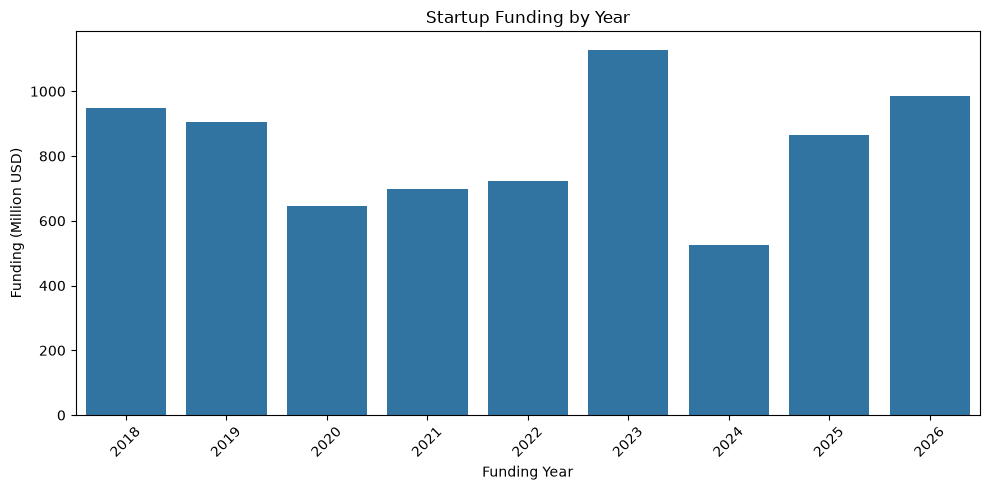

In [45]:
year_funding = (
    df.groupby('Funding_Year')['Funding_Amount_USD']
      .sum()
      .sort_index()
)
year_funding_million = year_funding / 1_000_000
plt.figure(figsize=(10, 5))

sns.barplot(
    x=year_funding_million.index,
    y=year_funding_million.values
)

plt.title("Startup Funding by Year")
plt.xlabel("Funding Year")
plt.ylabel("Funding (Million USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

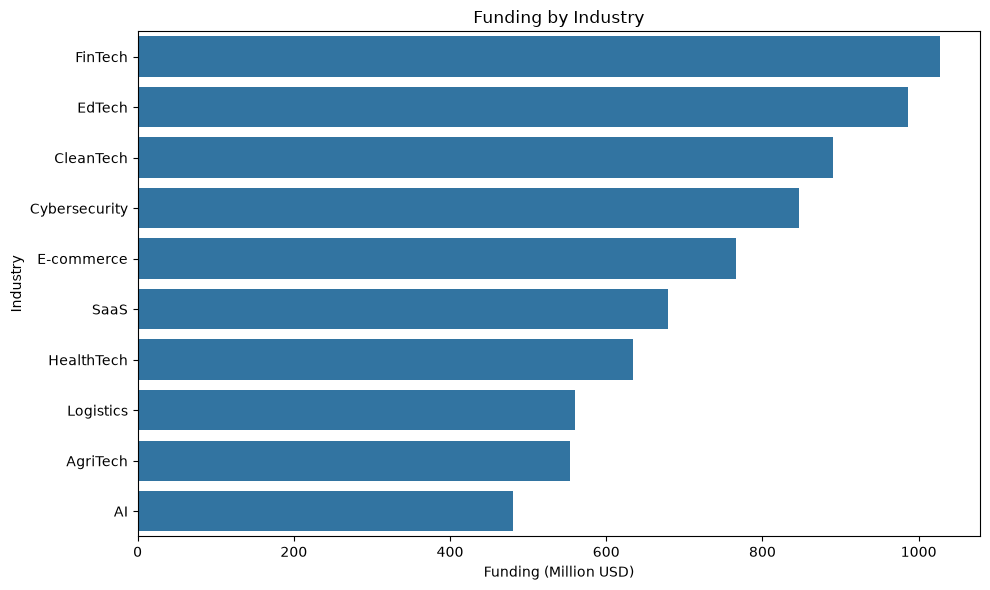

In [46]:
plt.figure(figsize=(10, 6))

industry_million = industry_funding / 1_000_000

sns.barplot(
    x=industry_million.values,
    y=industry_million.index
)

plt.title("Funding by Industry")
plt.xlabel("Funding (Million USD)")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

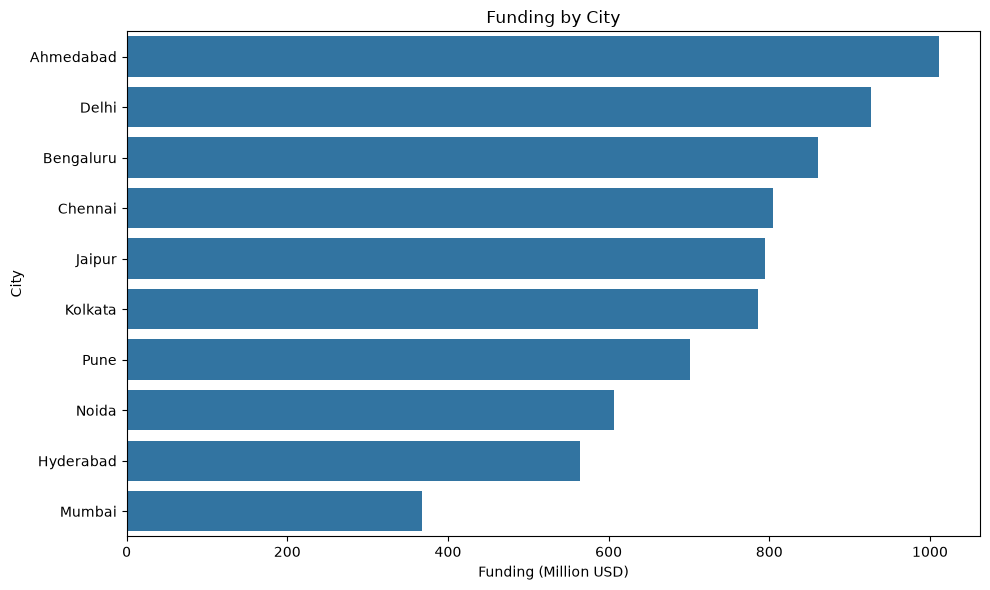

In [47]:
plt.figure(figsize=(10, 6))

city_million = city_funding / 1_000_000

sns.barplot(
    x=city_million.values,
    y=city_million.index
)

plt.title("Funding by City")
plt.xlabel("Funding (Million USD)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

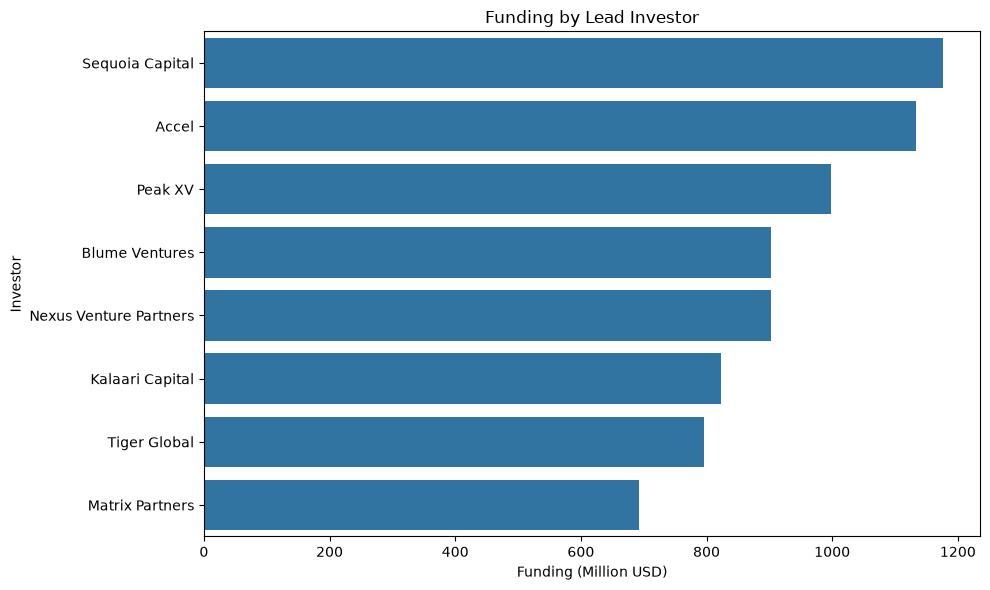

In [48]:
plt.figure(figsize=(10, 6))

investor_million = investor_funding / 1_000_000

sns.barplot(
    x=investor_million.values,
    y=investor_million.index
)

plt.title("Funding by Lead Investor")
plt.xlabel("Funding (Million USD)")
plt.ylabel("Investor")

plt.tight_layout()
plt.show()

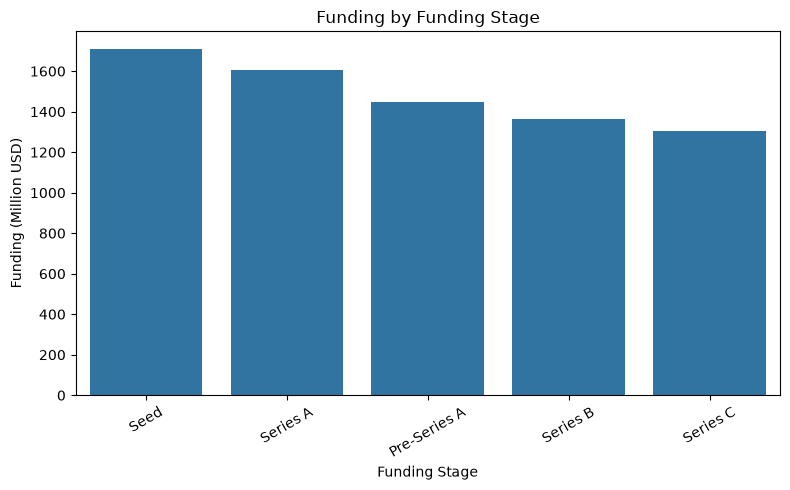

In [49]:
plt.figure(figsize=(8, 5))

stage_million = stage_funding / 1_000_000

sns.barplot(
    x=stage_million.index,
    y=stage_million.values
)

plt.title("Funding by Funding Stage")
plt.xlabel("Funding Stage")
plt.ylabel("Funding (Million USD)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [53]:
correlation = df[
    ['Funding_Amount_USD', 'Employees']
].corr()

print(correlation)

                    Funding_Amount_USD  Employees
Funding_Amount_USD             1.00000   -0.04107
Employees                     -0.04107    1.00000


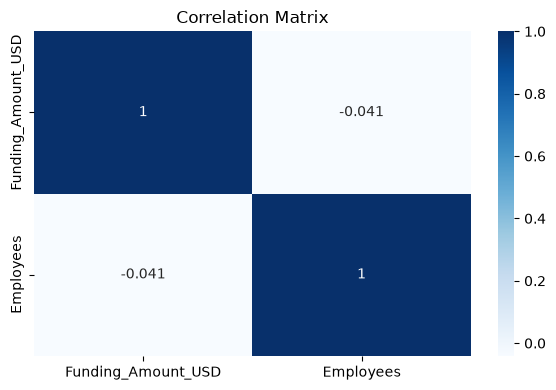

In [54]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

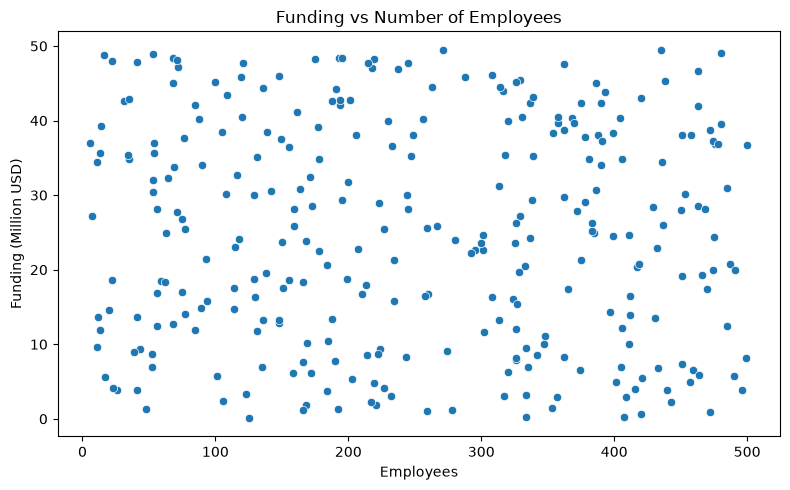

In [52]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Employees',
    y='Funding_Million_USD'
)

plt.title("Funding vs Number of Employees")
plt.xlabel("Employees")
plt.ylabel("Funding (Million USD)")

plt.tight_layout()
plt.show()